# **Project Name**  : e-Commerce Data Analysis

##### **Project Type**    - Exploratory Data Analysis
##### **Contribution**    - Individual
##### **Name**    - Madhuri Hawaldar

# **Project Introduction**



This project focuses on analyzing an e-commerce dataset to derive valuable insights into customer behavior, sales trends, and seller performance. The dataset, a comprehensive collection of customer, order, product, payment, and seller information, provides a rich ground for exploratory data analysis and understanding various facets of the online retail ecosystem.



## Objectives:



*   **Understand Customer Demographics and Spending Patterns**: Analyze customer distribution across cities and states, and evaluate their purchasing habits over time.
*   **Identify Key Performance Indicators (KPIs)**: Explore metrics such as total sales, monthly sales trends, order status distribution, and delivery times.
*   **Assess Product and Seller Performance**: Determine top-selling product categories, analyze revenue generated by individual sellers, and investigate correlations between product attributes and purchase frequency.
*   **Optimize Business Strategies**: Provide data-driven recommendations for targeted marketing, inventory management, and customer retention based on the insights gained.

Through various data manipulation techniques, statistical analysis, and data visualization, this project aims to uncover patterns and relationships that can inform strategic business decisions for an e-commerce platform.

## Handling Dataset

In [14]:
# Import necessory libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Import datasets
customers = pd.read_csv("/content/drive/MyDrive/ecommerce_files/customers.csv",encoding="latin1")
products = pd.read_csv("/content/drive/MyDrive/ecommerce_files/Products.csv",encoding="latin1")
orders = pd.read_csv("/content/drive/MyDrive/ecommerce_files/orders.csv",encoding="latin1")
order_items = pd.read_csv("/content/drive/MyDrive/ecommerce_files/order_items.csv",encoding="latin1")
payments = pd.read_csv("/content/drive/MyDrive/ecommerce_files/payments.csv",encoding="latin1")
sellers = pd.read_csv("/content/drive/MyDrive/ecommerce_files/sellers.csv",encoding="latin1")

In [16]:
# Merge datasets
df1 = pd.merge(orders, customers,on="customer_id",how="left")
df2 = pd.merge(df1, order_items,on="order_id",how="left")
df3 = pd.merge(df2, payments,on="order_id",how="left")
df4 = pd.merge(df3, products,on="product_id",how="left")
df_final = pd.merge(df4, sellers,on="seller_id",how="left")

In [17]:
# Copy final dataset
data = df_final.copy()
print("First 5 rows of dataset:\n")
data.head()

First 5 rows of dataset:



,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_name_length,product_description_length,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 0:00:00,7c396fd4830fd04220f754e42b4e5bff,3149,...,40.0,268.0,4.0,500.0,19.0,8.0,13.0,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 3:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 0:00:00,af07308b275d755c9edb36a90c618231,47813,...,29.0,178.0,1.0,400.0,19.0,13.0,19.0,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 8:38:49,2018-08-08 8:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 0:00:00,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,46.0,232.0,1.0,420.0,24.0,19.0,21.0,14840.0,guariba,SP


In [18]:
# Shape of dataset
print(f"Number of row are {data.shape[0]} and number of columns are {data.shape[1]}")

Number of row are 118434 and number of columns are 33


In [19]:
# Column names of dataset
data.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'payment_sequential',
       'payment_type', 'payment_installments', 'payment_value',
       'product category', 'product_name_length', 'product_description_length',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix',
       'seller_city', 'seller_state'],
      dtype='object')

## Dataset Description:

This project utilizes a comprehensive e-commerce dataset composed of several interconnected tables. Below is a brief description of each table and its key attributes:

*   **Customers Table**: Contains information about the unique customers.
    *   customer_id: Unique identifier for each customer.
    *   customer_unique_id: Unique identifier for each customer in the entire dataset (anonymized).
    *   customer_zip_code_prefix: First five digits of the customer's zip code.
    *   customer_city: City where the customer resides.
    *   customer_state: State where the customer resides.

*   **Orders Table**: Details about each purchase order.
    *   order_id: Unique identifier for each order.
    *   customer_id: Foreign key referencing the Customers table.
    *   order_status: Current status of the order (e.g., delivered, shipped, canceled).
    *   order_purchase_timestamp: Timestamp of when the order was purchased.
    *   order_approved_at: Timestamp of when the payment was approved.
    *   order_delivered_carrier_date: Timestamp of when the order was handed to the carrier.
    *   order_delivered_customer_date: Timestamp of when the order was delivered to the customer.
    *   order_estimated_delivery_date: Estimated delivery date of the order.

*   **Order Items Table**: Information about the items within each order.
    *   order_id: Foreign key referencing the Orders table.
    *   order_item_id: Sequential number identifying each item within the same order.
    *   product_id: Foreign key referencing the Products table.
    *   seller_id: Foreign key referencing the Sellers table.
    *   shipping_limit_date: Date by which the seller committed to ship the item.
    *   price: Price of the item.
    *   freight_value: Freight cost of the item.

*   **Payments Table**: Payment details for each order.
    *   order_id: Foreign key referencing the Orders table.
    *   payment_sequential: A sequence number for payments associated with the same order.
    *   payment_type: Method of payment (e.g., credit_card, boleto, voucher).
    *   payment_installments: Number of installments chosen for payment.
    *   payment_value: Total value of the payment.

*   **Products Table**: Details about the products sold.
    *   product_id: Unique identifier for each product.
    *   product_category: Main category of the product.
    *   product_name_length: Number of characters in the product name.
    *   product_description_length: Number of characters in the product description.
    *   product_photos_qty: Number of product photos.
    *   product_weight_g: Product weight in grams.
    *   product_length_cm: Product length in centimeters.
    *   product_height_cm: Product height in centimeters.
    *   product_width_cm: Product width in centimeters.

*   **Sellers Table**: Information about the sellers.
    *   seller_id: Unique identifier for each seller.
    *   seller_zip_code_prefix: First five digits of the seller's zip code.
    *   seller_city: City where the seller is located.
    *   seller_state: State where the seller is located.


This dataset allows for a comprehensive analysis of the e-commerce platform from various angles, including customer behavior, order fulfillment, product performance, and geographical distribution.

In [20]:
# dataset information
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 33 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       118434 non-null  object 
 1   customer_id                    118434 non-null  object 
 2   order_status                   118434 non-null  object 
 3   order_purchase_timestamp       118434 non-null  object 
 4   order_approved_at              118258 non-null  object 
 5   order_delivered_carrier_date   116360 non-null  object 
 6   order_delivered_customer_date  115037 non-null  object 
 7   order_estimated_delivery_date  118434 non-null  object 
 8   customer_unique_id             118434 non-null  object 
 9   customer_zip_code_prefix       118434 non-null  int64  
 10  customer_city                  118434 non-null  object 
 11  customer_state                 118434 non-null  object 
 12  order_item_id                 

# **Dataset Cleaning and Preprocessing**

## Data Cleaning Step 1: Identify Missing Values
**Reasoning:** Missing data can bias analyses or lead to inaccurate results. The approach taken here is to identify columns with missing values and apply appropriate strategies for imputation or removal.

In [21]:
# count missing values in each column
print("Missing values before cleaning:")
display(data.isna().sum())

Missing values before cleaning:


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,176
order_delivered_carrier_date,2074
order_delivered_customer_date,3397
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


## Handle Critical Missing Values

**Reasoning**:
Based on the initial assessment, some columns are critical for order and product analysis. Rows missing values in these key columns are likely incomplete or uninterpretable. This step specifically removes rows where order_item_id, product_id, seller_id, price, and freight_value are missing, as these are fundamental to understanding transactions.

In [22]:
# Drop null values
initial_rows_before_dropna = data.shape[0]
data.dropna(subset=data.columns, inplace=True)
rows_after_critical_dropna = data.shape[0]

print(f"Number of rows before dropping critical nulls: {initial_rows_before_dropna}")
print(f"Number of rows after dropping critical nulls: {rows_after_critical_dropna}")
print(f"Number of rows removed due to critical nulls: {initial_rows_before_dropna - rows_after_critical_dropna}")

print("\nMissing values after critical columns drop:")
display(data.isna().sum())

Number of rows before dropping critical nulls: 118434
Number of rows after dropping critical nulls: 113390
Number of rows removed due to critical nulls: 5044

Missing values after critical columns drop:


,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,0
order_delivered_carrier_date,0
order_delivered_customer_date,0
order_estimated_delivery_date,0
customer_unique_id,0
customer_zip_code_prefix,0


## Data Cleaning Step 2: Remove Duplicate Rows

**Reasoning**:
Duplicate records can skew analysis and lead to inaccurate conclusions. This step identifies and removes any exact duplicate rows from the DataFrame, ensuring that each observation is unique.

In [23]:
# Remove duplicate rows
initial_rows = data.shape[0]
data.drop_duplicates(inplace=True)
rows_after_duplicates = data.shape[0]
print(f"Number of rows before dropping duplicates: {initial_rows}")
print(f"Number of rows after dropping duplicates: {rows_after_duplicates}")
print(f"Number of duplicate rows removed: {initial_rows - rows_after_duplicates}")

Number of rows before dropping duplicates: 113390
Number of rows after dropping duplicates: 113390
Number of duplicate rows removed: 0


## Data Cleaning Step 3: Convert Data Types (Timestamps)

**Reasoning**:
Several columns contain timestamp information but are currently stored as object (string) type. Converting these to datetime objects is essential for accurate time-series analysis, calculations (e.g., delivery time), and proper plotting. This step converts all relevant timestamp columns.

In [24]:
# data type conversion
timestamp_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date',
    'shipping_limit_date'
]

for col in timestamp_columns:
    data[col] = pd.to_datetime(data[col], errors='coerce')

print("Timestamp columns converted to datetime format.")
print(data[timestamp_columns].info())

Timestamp columns converted to datetime format.
<class 'pandas.core.frame.DataFrame'>
Index: 113390 entries, 0 to 118433
Data columns (total 6 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_purchase_timestamp       113390 non-null  datetime64[ns]
 1   order_approved_at              113390 non-null  datetime64[ns]
 2   order_delivered_carrier_date   113390 non-null  datetime64[ns]
 3   order_delivered_customer_date  113390 non-null  datetime64[ns]
 4   order_estimated_delivery_date  113390 non-null  datetime64[ns]
 5   shipping_limit_date            113390 non-null  datetime64[ns]
dtypes: datetime64[ns](6)
memory usage: 6.1 MB
None


## Data Cleaning Step 4: Feature Engineering

**Reasoning**:
Creating new features can enrich the dataset for further analysis. This step involves calculating the total 'sales' per order item and extracting 'Year' and 'Month' components from the order_purchase_timestamp for temporal analysis.

In [25]:
# create columns 'sales', 'Year', 'Month'

# Calculate 'sales' (price + freight_value)
data['sales'] = data['price'] + data['freight_value']
print("\'sales\' column created successfully.")

# Extract 'Year' and 'Month' from 'order_purchase_timestamp'
data['Year'] = data['order_purchase_timestamp'].dt.year
data['Month'] = data['order_purchase_timestamp'].dt.month
print("\'Year\' and \'Month\' columns created successfully.")

print("\nFirst 5 rows of data with new features:")
display(data[['order_purchase_timestamp', 'sales', 'Year', 'Month']].head())

'sales' column created successfully.
'Year' and 'Month' columns created successfully.

First 5 rows of data with new features:


,order_purchase_timestamp,sales,Year,Month
0,2017-10-02 10:56:33,38.71,2017,10
1,2017-10-02 10:56:33,38.71,2017,10
2,2017-10-02 10:56:33,38.71,2017,10
3,2018-07-24 20:41:37,141.46,2018,7
4,2018-08-08 08:38:49,179.12,2018,8


#**Data Inspection and Visualization:**

In [26]:
# city of customer
data['customer_state'].unique()

array(['SP', 'BA', 'GO', 'RN', 'PR', 'RJ', 'RS', 'MG', 'SC', 'RR', 'PE',
       'TO', 'CE', 'DF', 'SE', 'MT', 'PB', 'PA', 'RO', 'ES', 'AP', 'MS',
       'MA', 'PI', 'AL', 'AC', 'AM'], dtype=object)

In [27]:
# city of seller
data['seller_state'].unique()

array(['SP', 'MG', 'ES', 'RS', 'DF', 'PR', 'SC', 'RJ', 'GO', 'BA', 'MA',
       'PB', 'PE', 'CE', 'MT', 'PI', 'RN', 'MS', 'PA', 'AM', 'SE', 'RO'],
      dtype=object)

In [28]:
# different payment types
data['payment_type'].unique()

array(['credit_card', 'voucher', 'UPI', 'debit_card'], dtype=object)

In [29]:
# number of installments
data['payment_installments'].unique()

array([ 1.,  3.,  6., 10.,  4.,  2.,  8.,  9.,  7.,  5., 13., 12., 15.,
       14., 21., 18., 24., 17., 11., 20., 23., 16., 22.,  0.])

In [30]:
# different product categories
data['product category'].unique()

array(['housewares', 'perfumery', 'automotive', 'pet Shop',
       'stationary store', 'Furniture Decoration', 'Furniture office',
       'Garden tools', 'computer accessories', 'bed table bath', 'toys',
       'Construction Tools Construction', 'telephony', 'HEALTH BEAUTY',
       'electronics', 'babies', 'Cool Stuff', 'Watches present',
       'climatization', 'sport leisure', 'General Interest Books',
       'electrostile', 'foods', 'Bags Accessories',
       'Fashion Underwear and Beach Fashion',
       'Fashion Bags and Accessories', 'musical instruments',
       'Construction Tools Illumination', 'technical books',
       'Construction Tools Garden', 'home appliances', 'Market Place',
       'Agro Industria e Comercio', 'party articles', 'House comfort',
       'cds music dvds', 'Industry Commerce and Business',
       'Games consoles', 'Furniture', 'CONSTRUCTION SECURITY TOOLS',
       'fixed telephony', 'drinks',
       'Furniture Kitchen Service Area Dinner and Garden',
      

In [52]:
# number of customers
data['customer_id'].nunique()

95128

In [53]:
# count of orders
data['order_id'].nunique()

95128

In [54]:
# number of sellers
data['seller_id'].nunique()

2914

In [58]:
# total sales
data['sales'].sum().round(2)

np.float64(15898189.88)

## Visualization 1: Monthly Sales Trend

**Reasoning**:
Visualizing monthly sales trends helps identify patterns, seasonality, and overall growth or decline in sales over time. This is crucial for strategic planning and forecasting. The order_purchase_timestamp column will be used to extract month information and the price column for sales.

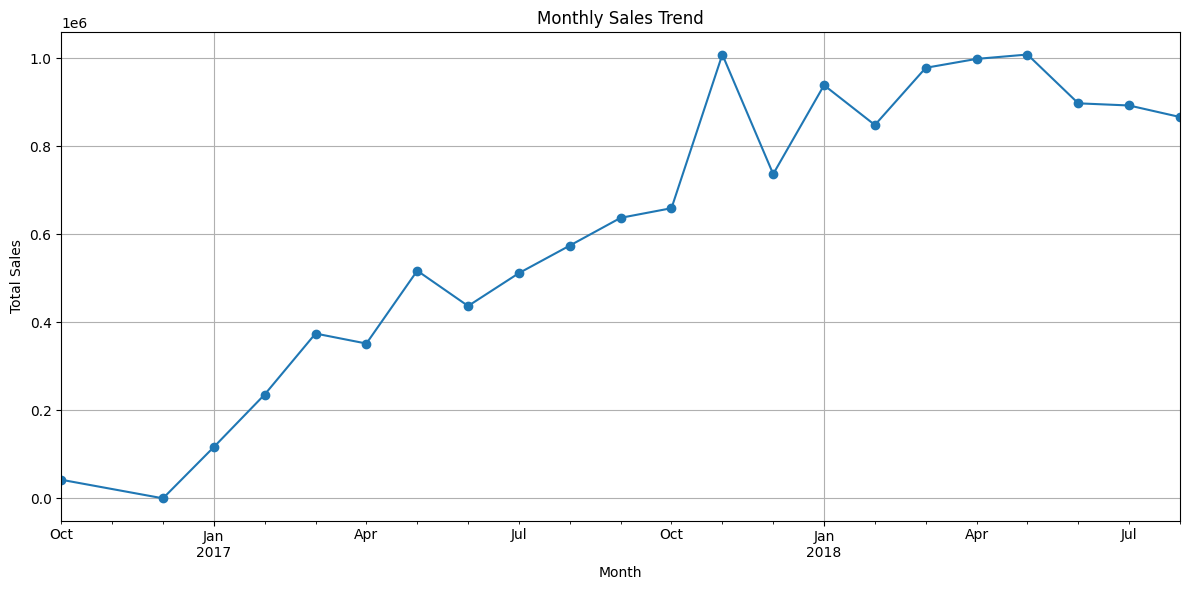

In [32]:
# extract month and calculate monthwise sale
data['month'] = data['order_purchase_timestamp'].dt.to_period('M')
monthly_sales = data.groupby('month')['price'].sum()

# plot trend
plt.figure(figsize=(12, 6))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

**Result**: The line plot shows the progression of total sales month-over-month. We can observe a general upward trend in sales, with some noticeable fluctuations. There are clear peaks, especially towards the end of the year, suggesting potential seasonality in sales.

## Visualization 2: Orders by Status

**Reasoning**:
Understanding the distribution of order statuses (e.g., delivered, shipped, canceled) provides insights into operational efficiency and potential bottlenecks. A bar chart is effective for comparing counts across different categories.

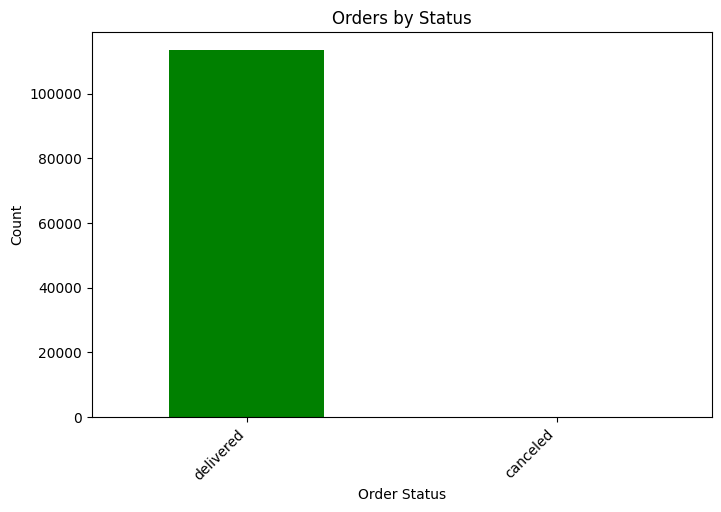

In [33]:
# count of each order status
status_counts = data['order_status'].value_counts()

# visualize with bar chart
plt.figure(figsize=(8, 5))
status_counts.plot(kind='bar',color='green')
plt.title("Orders by Status")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

**Result**: This bar chart reveals that the vast majority of orders have a 'delivered' status. This indicates a high rate of successful deliveries, which is positive for operational efficiency. The presence of a small number of 'canceled' orders might warrant further investigation to understand the reasons behind them.

## Visualization 3: Delivery Time Distribution

**Reasoning**:
Analyzing the distribution of delivery times helps assess customer satisfaction and logistical performance. A histogram can show the frequency of different delivery durations.

Average Delivery Time: 12.01 days


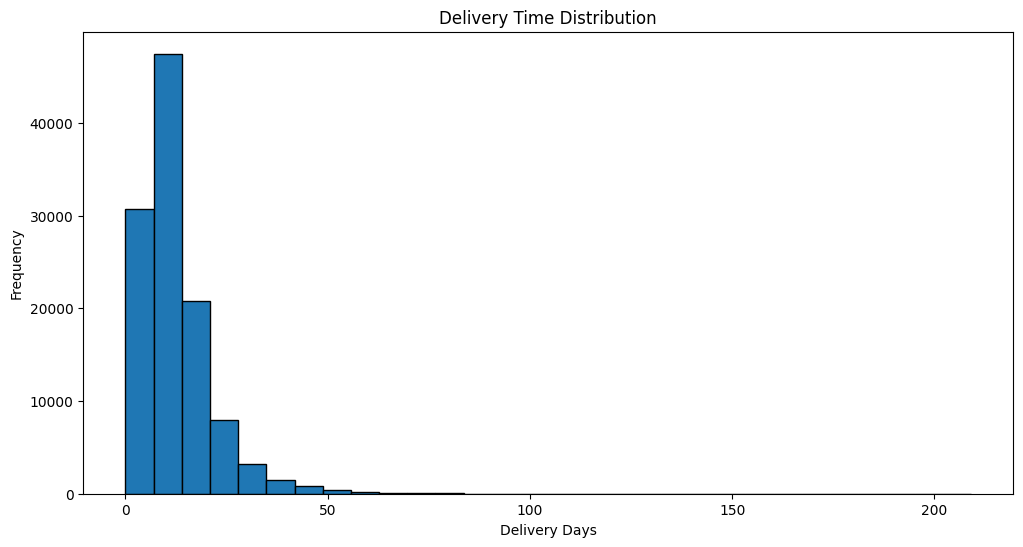

In [34]:
# calculate delivery time
data['delivery_days'] = (data['order_delivered_customer_date'] -data['order_purchase_timestamp']).dt.days

# average delivery time
avg_delivery = data['delivery_days'].mean()
print(f"Average Delivery Time: {avg_delivery:.2f} days")

# plotting distribution of delivery time
plt.figure(figsize=(12, 6))
data['delivery_days'].dropna().plot(kind='hist', bins=30, edgecolor='black')
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.show()

**Result**: The histogram illustrates the distribution of delivery times in days. The average delivery time is approximately 12.01 days. The distribution shows that most deliveries occur within a relatively short period, but there's a tail indicating some orders take longer to reach customers. This helps in understanding typical delivery durations and identifying potential outliers.

## Visualization 4: Revenue by Payment Type

**Reasoning**:
Understanding which payment types generate the most revenue can inform financial strategies and marketing efforts. A bar chart effectively compares revenue across different payment methods.

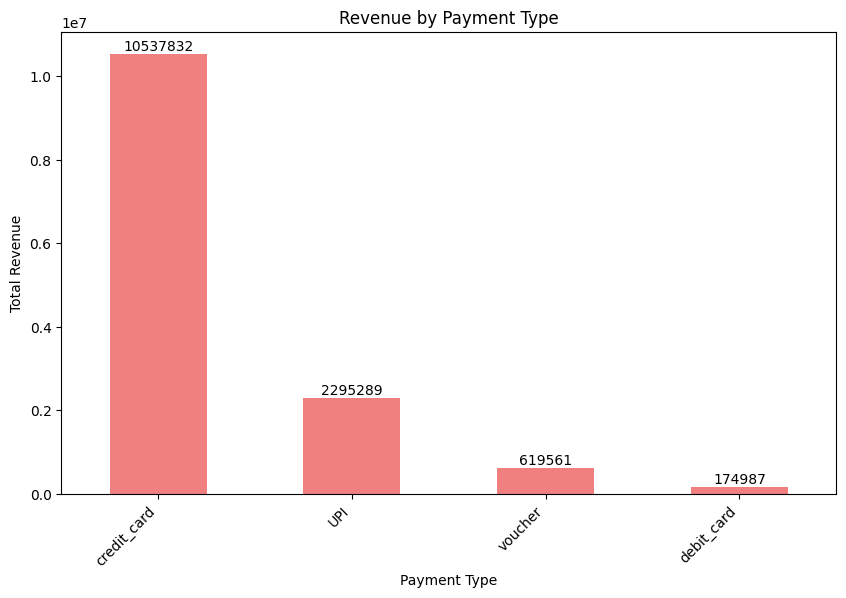

In [35]:
# calculate revenue generated by each payment type
payment_sales = data.groupby('payment_type')['price'].sum().sort_values(ascending=False)

# visualize with bar chart
plt.figure(figsize=(10, 6))
plots=payment_sales.plot(kind='bar', color='lightcoral')
plt.title("Revenue by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45, ha='right')
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=10)
plt.show()

**Result**: This bar chart clearly indicates that 'credit_card' is the dominant payment method, contributing the highest amount of revenue. 'UPI' is the second most common payment method. This insight is valuable for understanding customer payment preferences and optimizing payment processing strategies.

## Visualization 5: Order Price Distribution

**Reasoning**:
Analyzing the distribution of order prices can reveal common price points, premium segments, or outlier transactions. A histogram is suitable for showing the frequency of different price ranges.

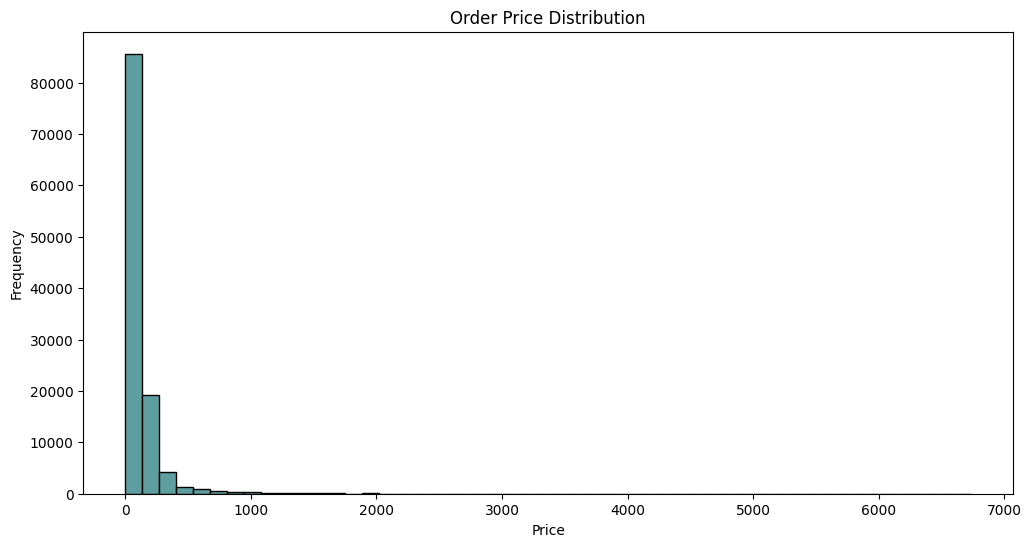

In [36]:
# plot distribution of order price
plt.figure(figsize=(12, 6))
data['price'].plot(kind='hist', bins=50, edgecolor='black', color='cadetblue')
plt.title("Order Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**Result**: The histogram of order prices shows that a large number of orders fall into the lower price ranges, with fewer orders for higher-priced items. This suggests that the e-commerce platform caters more to budget-conscious buyers or sells a higher volume of lower-cost goods.


## Visualization 6: Freight Value vs Product Price

**Reasoning**:
To explore the relationship between product price and the associated freight value, a scatter plot is an effective tool. It can reveal if more expensive items incur higher shipping costs or if there's no clear correlation.

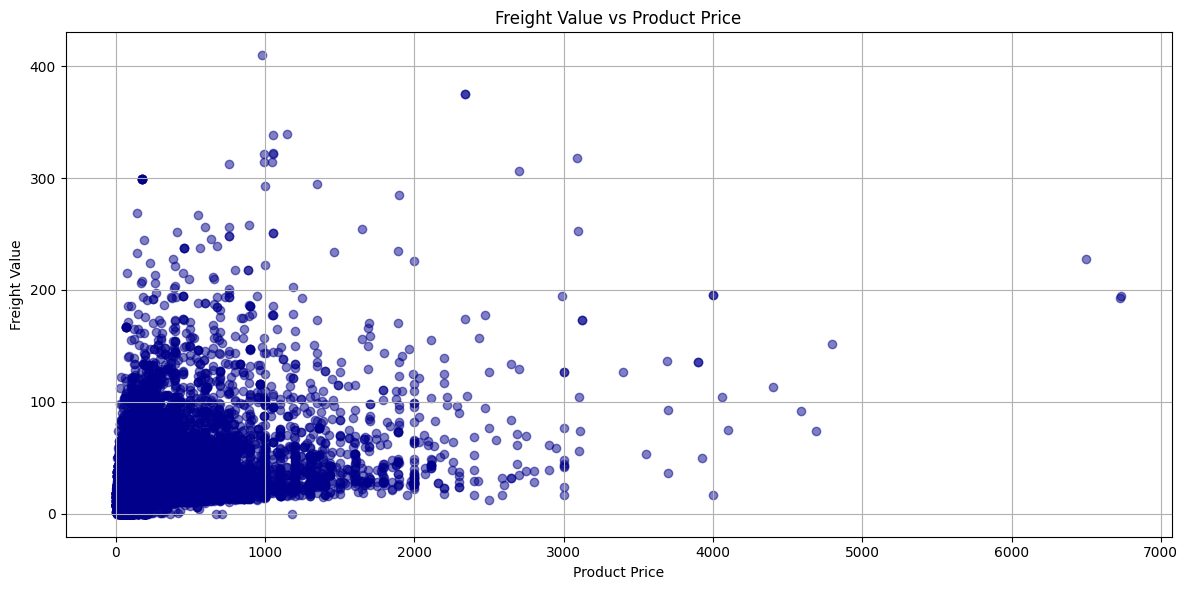

In [37]:
# plotting correlation between Freight Value and Product Price
plt.figure(figsize=(12, 6))
plt.scatter(data['price'], data['freight_value'], alpha=0.5, color='darkblue')
plt.title('Freight Value vs Product Price')
plt.xlabel('Product Price')
plt.ylabel('Freight Value')
plt.grid(True)
plt.tight_layout()
plt.show()

**Result**: The scatter plot between product price and freight value shows a general trend where higher-priced products tend to have higher freight values, although there's considerable variability. The correlation is not very strong, suggesting other factors also influence freight costs.

## Visualization 7: Items Per Order Distribution

**Reasoning**:
Understanding how many items customers typically purchase in a single order can provide insights into shopping behavior. A histogram of the number of items per order will show the frequency of different item counts.

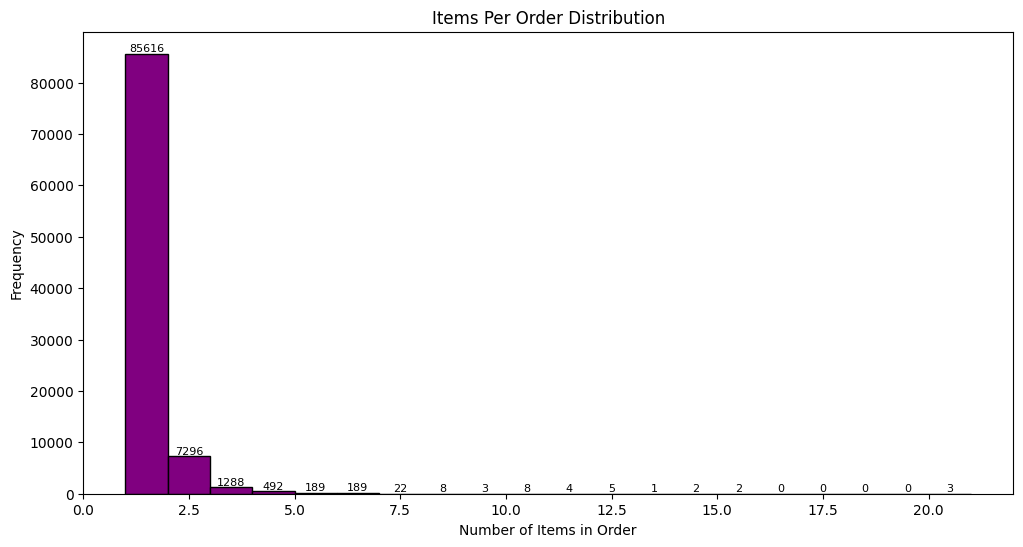

In [38]:
# calculate items per order
items_per_order = data.groupby('order_id')['order_item_id'].max()

# plotting distribution
plt.figure(figsize=(12, 6))
plots=items_per_order.plot(kind='hist', bins=20, edgecolor='black', color='purple')
plt.title('Items Per Order Distribution')
plt.xlabel('Number of Items in Order')
plt.ylabel('Frequency')
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=8)
plt.show()

**Result**: This histogram shows that the vast majority of orders consist of a single item. The frequency drops significantly as the number of items per order increases. This suggests that most customers tend to buy one item at a time, which can influence inventory management and packaging strategies.

## Visualization 8: Price Distribution by Top 5 Product Categories

**Reasoning**:
A box plot is excellent for visualizing the distribution of a numerical variable (price) across different categorical groups (top product categories). It allows us to compare median prices, spread, and identify outliers for each category.

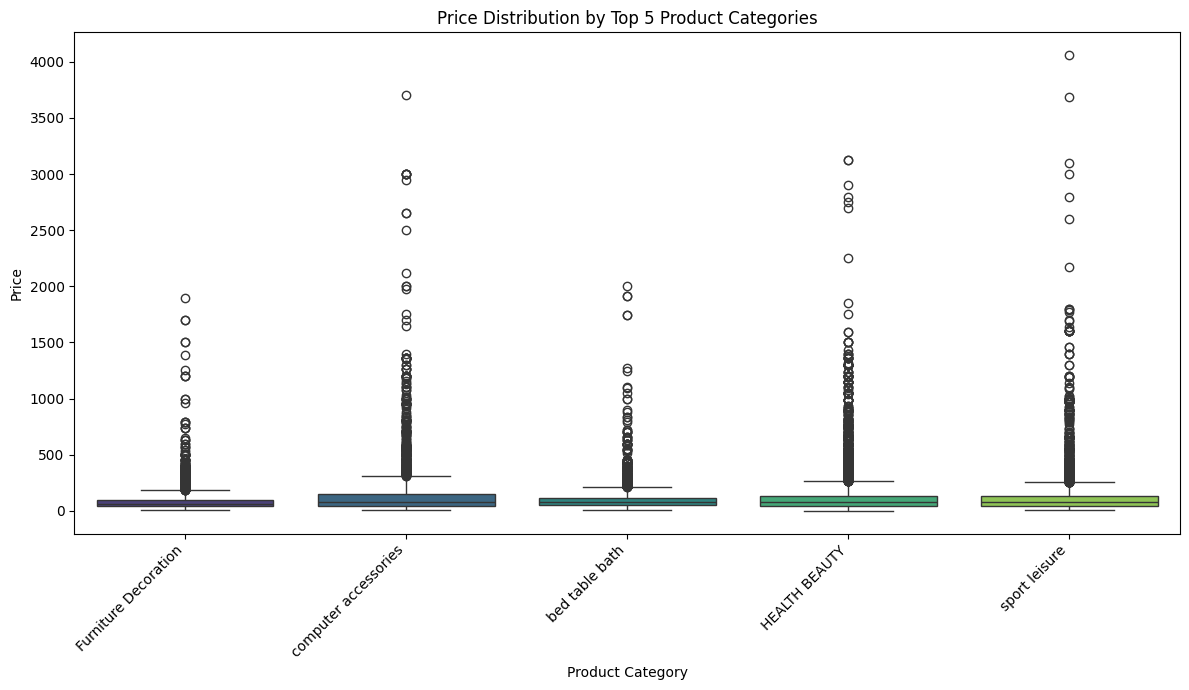

In [39]:
# price for top 5 categories
top_5_categories = data['product category'].value_counts().head(5).index
data_top_5_categories = data[data['product category'].isin(top_5_categories)]

# visualize distribution with boxplot
plt.figure(figsize=(12, 7))
sns.boxplot(x='product category', y='price', data=data_top_5_categories, palette='viridis', hue='product category', legend=False)
plt.title('Price Distribution by Top 5 Product Categories')
plt.xlabel('Product Category')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Result**: The box plot compares the price distribution across the top 5 product categories. It allows us to see the median price, the interquartile range, and potential outliers for each category. For example, 'bed table bath' and 'HEALTH BEAUTY' show a wide price range.

## Visualization 9: Top 10 Cities by Sales

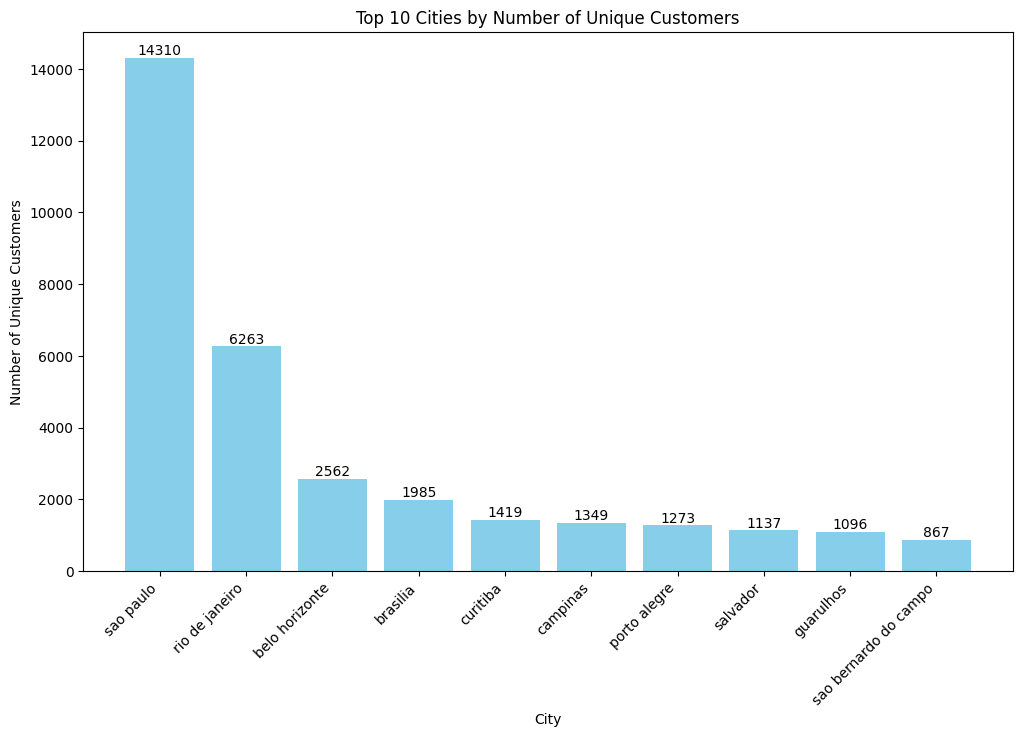

In [40]:
# sales for top 10 cities
customers_by_city = data.groupby('customer_city')['customer_unique_id'].nunique().reset_index()
customers_by_city.rename(columns={'customer_unique_id': 'number_of_customers'}, inplace=True)
top_cities_by_customers = customers_by_city.sort_values(by='number_of_customers', ascending=False).head(10)

# visualize with bar chart
plt.figure(figsize=(12, 7))
plots=plt.bar(top_cities_by_customers['customer_city'], top_cities_by_customers['number_of_customers'], color='skyblue')
plt.xlabel('City')
plt.ylabel('Number of Unique Customers')
plt.title('Top 10 Cities by Number of Unique Customers')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=10)
plt.show()

**Result**: This bar chart clearly shows 'sao paulo' has the highest number of unique customers by a significant margin, followed by 'rio de janeiro' and 'belo horizonte'. This highlights key geographical hubs for customer concentration.

## Visualization 10: Number of Orders Per Year

**Reasoning**:
Now that the 'Year' column is available, we can group the data by 'Year' and count the unique order_id values to determine the total number of orders for each year. A bar chart is then used for effective visualization of these annual order counts.

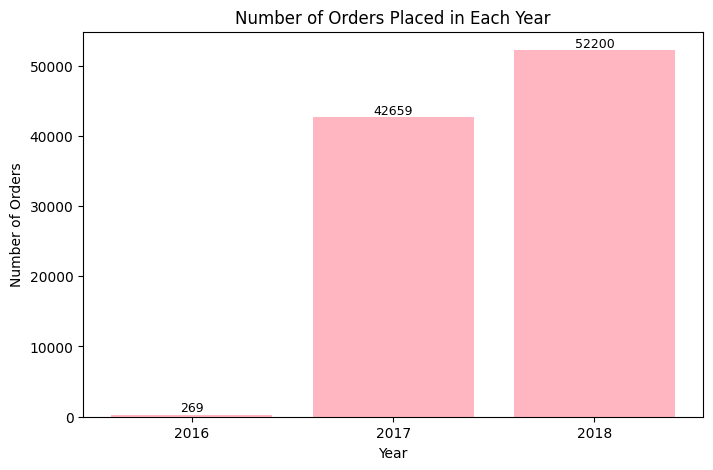

In [41]:
# count of orders per year
orders_per_year = data.groupby('Year')['order_id'].nunique().reset_index()
orders_per_year.rename(columns={'order_id': 'Number of Orders'}, inplace=True)

# visualize with bar chart
plt.figure(figsize=(8, 5))
plots=plt.bar(orders_per_year['Year'].astype(int), orders_per_year['Number of Orders'], color='lightpink')
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.title('Number of Orders Placed in Each Year')
plt.xticks(orders_per_year['Year'].astype(int))
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=9)
plt.show()


**Result**: The bar chart displays the total number of orders placed in each year. There's a clear growth trend from 2016 to 2018, with 2018 having the highest number of orders. This indicates a growing customer base and increasing activity on the platform.


## Visualization 11: Total Sales Per Category

**Reasoning**:
To understand which product categories are driving the most sales, a bar chart of 'Total Sales Per Category' is highly effective. I will use the category_sales DataFrame, which contains the sum of 'sales' for each 'product category', and display the top categories for better readability.

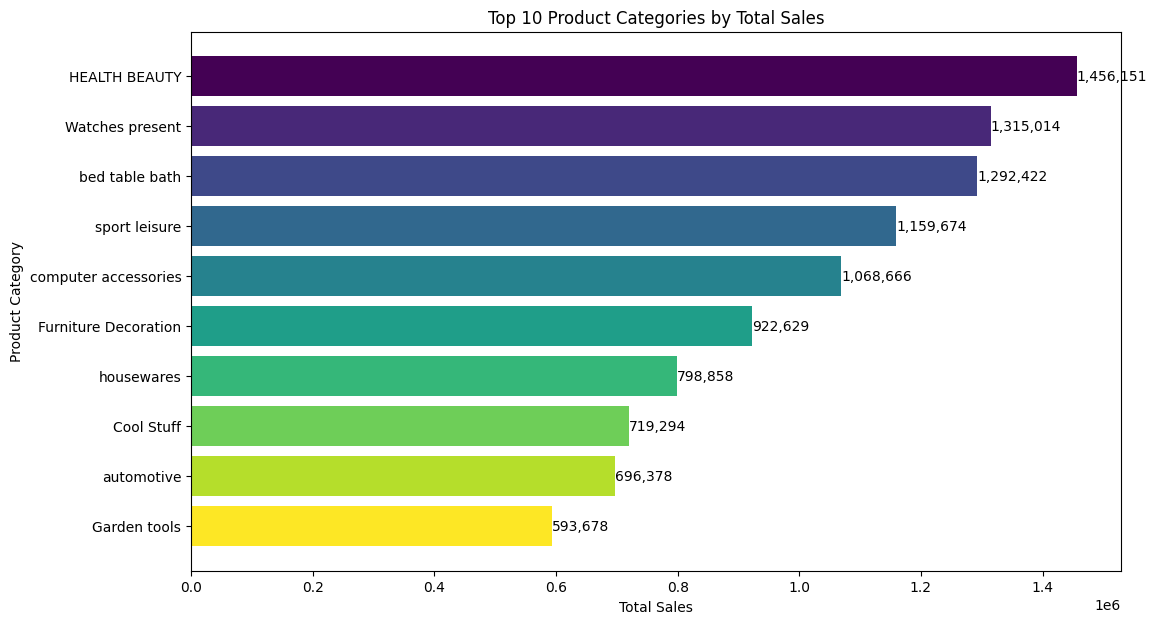

In [42]:
# sales for each product category
category_sales = data.groupby('product category')['sales'].sum().reset_index()
top_categories = category_sales.sort_values(by='sales', ascending=False).head(10)

# visualize with horizontal bar chart
plt.figure(figsize=(12, 7))
# Use the recommended method to get the colormap and sample colors
viridis_cmap = plt.colormaps.get_cmap('viridis')
colors_for_bars = viridis_cmap(np.linspace(0, 1, len(top_categories)))
plots = plt.barh(top_categories['product category'], top_categories['sales'], color=colors_for_bars)
plt.title('Top 10 Product Categories by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Category')
plt.gca().invert_yaxis() # Invert y-axis to have the highest value on top

# Add annotations
for bar in plots:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():,.0f}', va='center', ha='left', fontsize=10)
plt.show()

**Result**: This horizontal bar chart (now with distinct viridis colors) shows 'HEALTH BEAUTY' as the top-selling category, followed by 'Watches present' and 'bed table bath'. This identifies the most lucrative product segments on the platform.

## Visualization 12: Percentage of Orders Paid in Installments

**Reasoning**:
To visualize the percentage of orders paid in installments, a pie chart is an excellent choice as it clearly represents parts of a whole. I will use the percentage_installments value calculated previously to create a chart showing the proportion of orders paid in installments versus those paid in a single transaction.

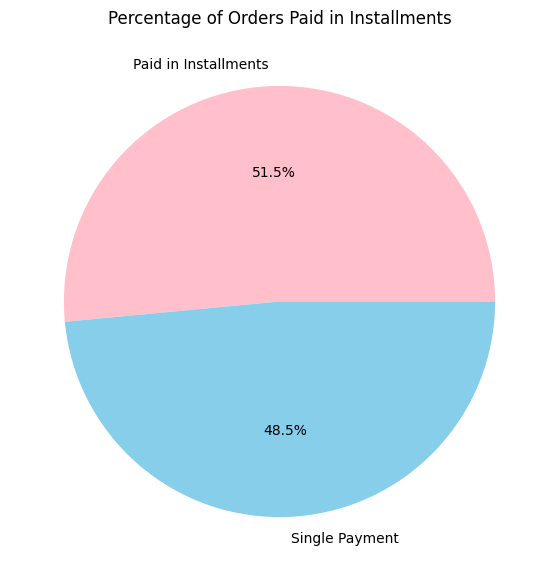

In [43]:
# count orders
total_orders = data['order_id'].nunique()
# orders with installments
orders_with_installments = data[data['payment_installments'] > 1]['order_id'].nunique()
# orders without installments
orders_without_installments = total_orders - orders_with_installments

# calculate percentage
percentage_installments = (orders_with_installments / total_orders) * 100
percentage_single_payment = (orders_without_installments / total_orders) * 100

labels = ['Paid in Installments', 'Single Payment']
sizes = [percentage_installments, percentage_single_payment]
colors = ['pink','skyblue']

# visualize with pie chart
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('Percentage of Orders Paid in Installments')
plt.show()

**Result**: The pie chart illustrates that a slightly higher percentage of orders are paid in installments (51.5%) compared to single payments (48.5%). This indicates that installment payment options are popular among customers.

## Visualization 13: Number of Customers from Each State

**Reasoning**:
A bar chart is an effective way to visualize the number of customers from each state, especially for comparing the top states. I will use the customers_by_state DataFrame to create a bar chart of the top 10 states by customer count.

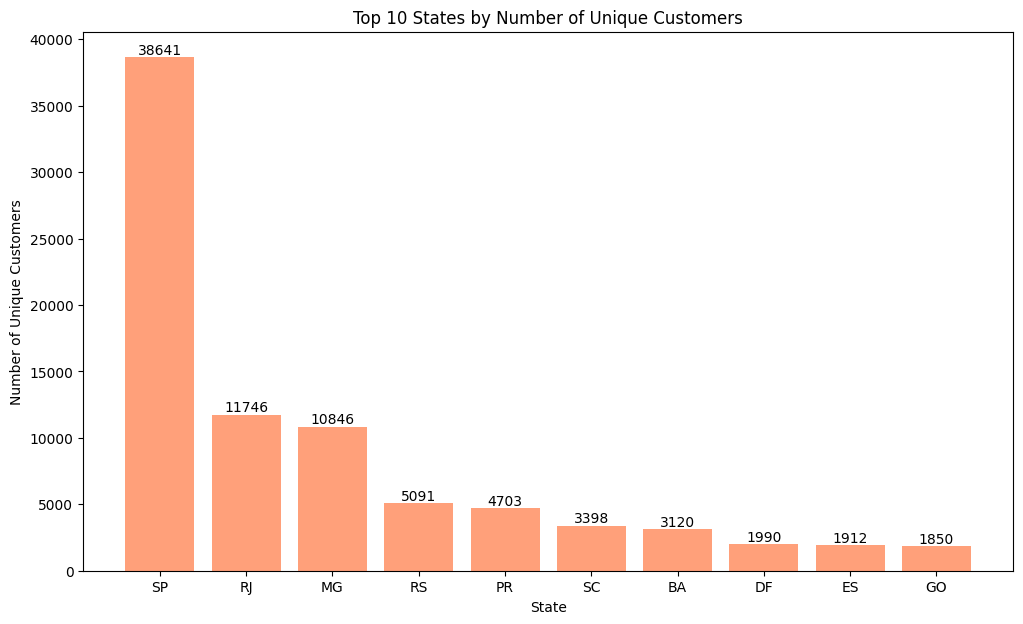

In [44]:
# count of customers in each state
customers_by_state = data.groupby('customer_state')['customer_unique_id'].nunique().reset_index()
customers_by_state.rename(columns={'customer_unique_id': 'number_of_customers'}, inplace=True)
# sorting
top_states = customers_by_state.sort_values(by='number_of_customers', ascending=False).head(10)

# visualize with bar chart
plt.figure(figsize=(12, 7))
plots=plt.bar(top_states['customer_state'], top_states['number_of_customers'], color='lightsalmon')
plt.xlabel('State')
plt.ylabel('Number of Unique Customers')
plt.title('Top 10 States by Number of Unique Customers')
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=10)
plt.show()

**Result**: Similar to cities, the state of 'SP' (São Paulo) has the overwhelming majority of unique customers, followed by 'RJ' (Rio de Janeiro) and 'MG' (Minas Gerais). This confirms the high customer concentration in specific regions.

## Visualization 14: Number of Orders Per Month in 2018

**Reasoning**:
To visualize the number of orders per month in 2018, I will first ensure the 'order_purchase_timestamp' is in datetime format, then filter the data for the year 2018. Subsequently, I'll group the data by month and count the unique order_id values to get the monthly order counts. Finally, a bar chart will be generated to display these counts.

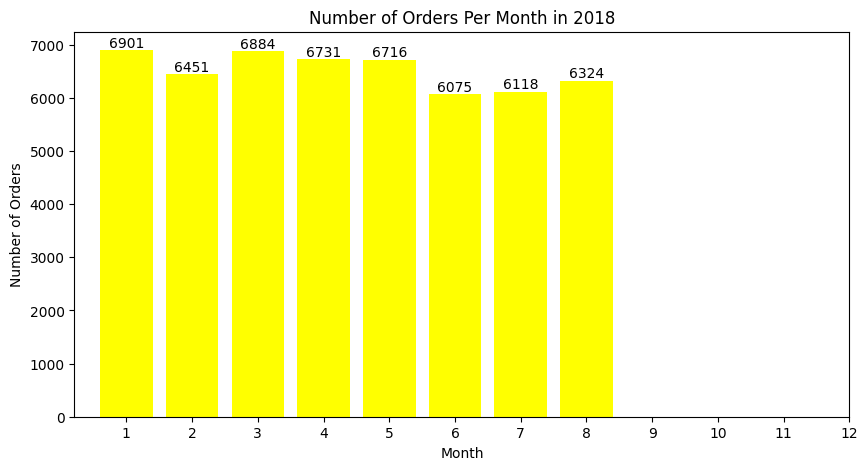

In [45]:
# count orders per month in the year 2018
orders_2018 = data[data['Year'] == 2018]
orders_per_month_2018 = orders_2018.groupby(orders_2018['order_purchase_timestamp'].dt.month)['order_id'].nunique().reset_index()
orders_per_month_2018.columns = ['Month', 'Number of Orders']

# visualize with bar chart
plt.figure(figsize=(10, 5))
plots=plt.bar(orders_per_month_2018['Month'], orders_per_month_2018['Number of Orders'], color='yellow')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Number of Orders Per Month in 2018')
plt.xticks(range(1, 13)) # Ensure all 12 months are shown on x-axis
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=10)
plt.show()

**Result**: This bar chart shows the monthly distribution of orders for the year 2018. The number of orders remains relatively stable across the months, with slight variations, allowing for analysis of monthly trends within that specific year.

## Visualization 15: Average Number of Products Per Order by Customer City

**Reasoning**:
To understand purchasing habits across different regions, I will calculate the average number of products per order for each customer city. This involves grouping the data by order_id and customer_city to count items per order, then averaging these counts per city. Finally, a bar chart will display the top cities by this metric.

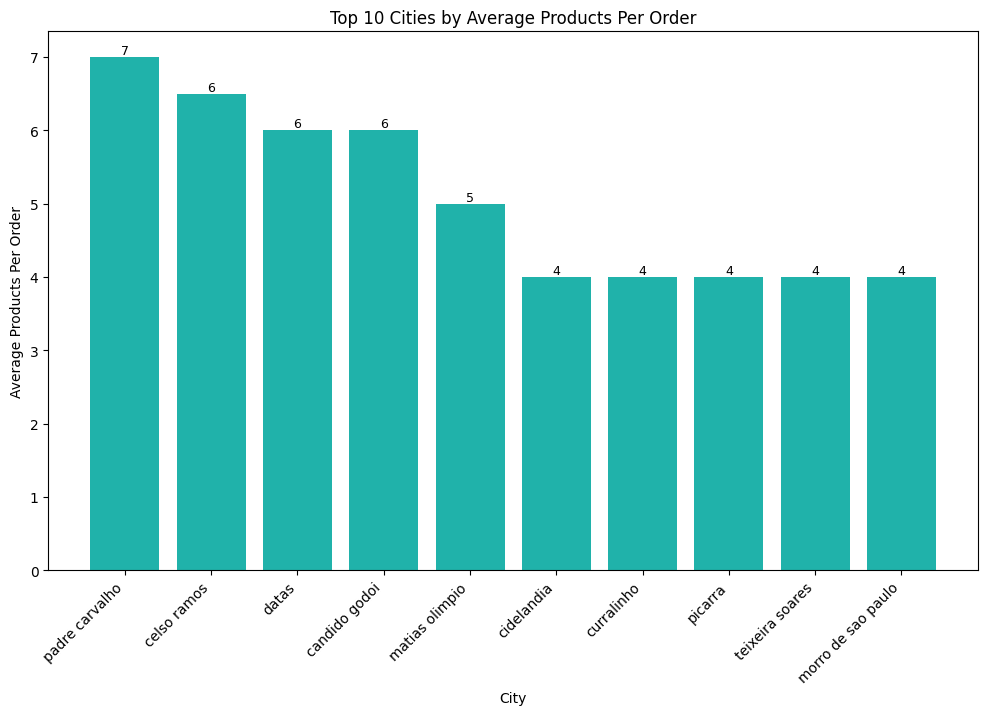

In [46]:
# count of products per order for citywise
products_per_order = data.groupby(['order_id', 'customer_city'])['order_item_id'].max().reset_index()
average_products_by_city = products_per_order.groupby('customer_city')['order_item_id'].mean().reset_index()
average_products_by_city.rename(columns={'order_item_id': 'average_products_per_order'}, inplace=True)

top_cities_avg_products = average_products_by_city.sort_values(by='average_products_per_order', ascending=False).head(10)

# Visualize the top 10 cities with bar chart
plt.figure(figsize=(12, 7))
plots=plt.bar(top_cities_avg_products['customer_city'], top_cities_avg_products['average_products_per_order'], color='lightseagreen')
plt.xlabel('City')
plt.ylabel('Average Products Per Order')
plt.title('Top 10 Cities by Average Products Per Order')
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
for bar in plots.patches:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), int(bar.get_height()), ha='center', va='bottom', size=9)
plt.show()

**Result**: This chart shows which cities have the highest average number of products per order. While 'sao paulo' has the most customers, other cities like 'padre carvalho' and 'celso ramos' show a higher average number of products per order. This can indicate different purchasing behaviors in various regions.

## Visualization 16: Percentage of Total Revenue by Product Category

**Reasoning**:
To understand which product categories are the most significant contributors to the overall revenue, I will calculate the percentage of total revenue for each category. This involves ensuring the 'sales' column is present, summing it to get the total revenue, and then dividing each category's sales by this total. The top contributing categories will then be visualized using a bar chart.

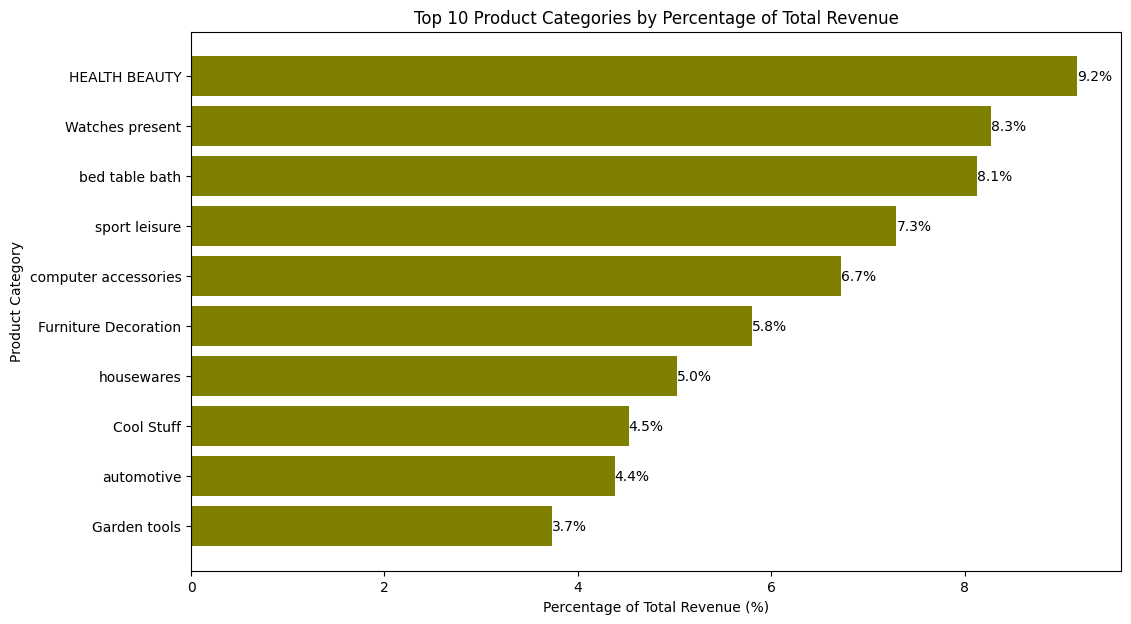

In [47]:
# calculate revenue
total_revenue = data['sales'].sum()
# revenue per product category
category_sales['percentage_of_total_revenue'] = (category_sales['sales'] / total_revenue) * 100

top_percentage_categories = category_sales.sort_values(by='percentage_of_total_revenue', ascending=False).head(10)

# visualize with horizontal bar chart
plt.figure(figsize=(12, 7))
plots=plt.barh(top_percentage_categories['product category'], top_percentage_categories['percentage_of_total_revenue'], color='olive')
plt.title('Top 10 Product Categories by Percentage of Total Revenue')
plt.xlabel('Percentage of Total Revenue (%)')
plt.ylabel('Product Category')
plt.gca().invert_yaxis() # Invert y-axis to have the highest value on top
# Add annotations
for bar in plots:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():.1f}%', va='center', ha='left', fontsize=10)
plt.show()

**Result**: This horizontal bar chart with annotations highlights 'HEALTH BEAUTY' (9.2%) and 'Watches present' (8.3%) as the top contributors to the total revenue, providing a clear picture of the platform's revenue drivers.

## Visualization 17: Correlation between Product Price and Number of Purchases

**Reasoning**:
To analyze the relationship between product price and its purchase frequency, we need to first calculate how many times each unique product has been purchased (by counting unique order_id for each product_id). We also need the price associated with each product. After obtaining these, we can merge them and visualize their correlation using a scatter plot. A numerical correlation coefficient will also be calculated to quantify the relationship.

Correlation between product price and number of purchases: -0.03


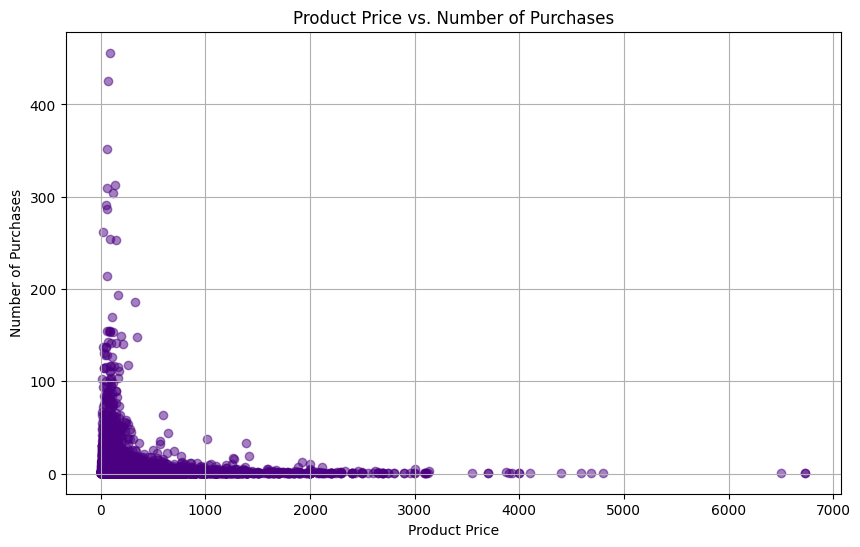

In [48]:
# purchase count
product_purchase_count = data.groupby('product_id')['order_id'].nunique().reset_index()
product_purchase_count.rename(columns={'order_id': 'purchase_count'}, inplace=True)

# Get unique product prices (assuming price is consistent for a given product_id)
product_prices = data.groupby('product_id')['price'].mean().reset_index()

# Merge purchase count and price
product_data = pd.merge(product_prices, product_purchase_count, on='product_id', how='inner')

# Calculate the correlation
correlation = product_data['price'].corr(product_data['purchase_count'])
print(f"Correlation between product price and number of purchases: {correlation:.2f}")

# Visualize the correlation with a scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(product_data['price'], product_data['purchase_count'], alpha=0.5,color='indigo')
plt.title('Product Price vs. Number of Purchases')
plt.xlabel('Product Price')
plt.ylabel('Number of Purchases')
plt.grid(True)
plt.show()

**Result**: The scatter plot and the calculated correlation of -0.03 suggest a very weak, almost negligible, negative correlation between product price and the number of purchases. This means that, on average, there's no strong tendency for cheaper products to be purchased significantly more often, or expensive products significantly less often.

## Visualization 18: Total Revenue Generated by Each Seller

**Reasoning**:
To identify the top-performing sellers, it's essential to calculate the total revenue generated by each. This involves grouping the data DataFrame by seller_id and summing the sales for each. A bar chart will then effectively visualize the top sellers by their revenue.

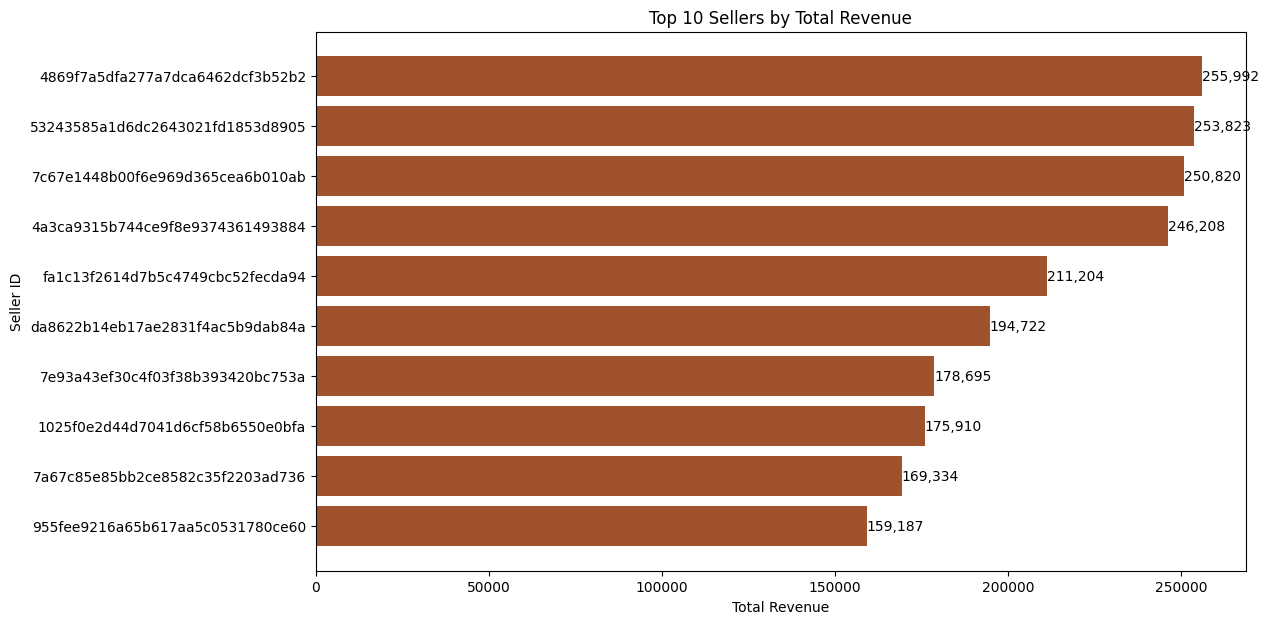

In [49]:
# revenue by seller
seller_revenue = data.groupby('seller_id')['sales'].sum().reset_index()
seller_revenue.rename(columns={'sales': 'total_revenue'}, inplace=True)

top_sellers_revenue = seller_revenue.sort_values(by='total_revenue', ascending=False).head(10)

# visualize with hirizontal bar chart
plt.figure(figsize=(12, 7))
plots=plt.barh(top_sellers_revenue['seller_id'], top_sellers_revenue['total_revenue'], color='sienna')
plt.title('Top 10 Sellers by Total Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Seller ID')
plt.gca().invert_yaxis() # Invert y-axis to have the highest value on top
# Add annotations
for bar in plots:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2, f'{bar.get_width():,.0f}', va='center', ha='left', fontsize=10)
plt.show()

**Result**: This horizontal bar chart with annotations identifies the top-performing sellers based on the total revenue they generate. Sellers like '4869f7a5dfa277a7dca6462dcf3b52b2' and '53243585a1d6dc2643021fd1853d8905' are clear leaders, contributing the most revenue to the platform.

## Visualization 19:  Heatmap of Numerical Features Correlation

This heatmap visualizes the correlation matrix of all numerical features in the data DataFrame.

**Reasoning:** A heatmap is an excellent tool to quickly identify strong positive or negative correlations between variables.

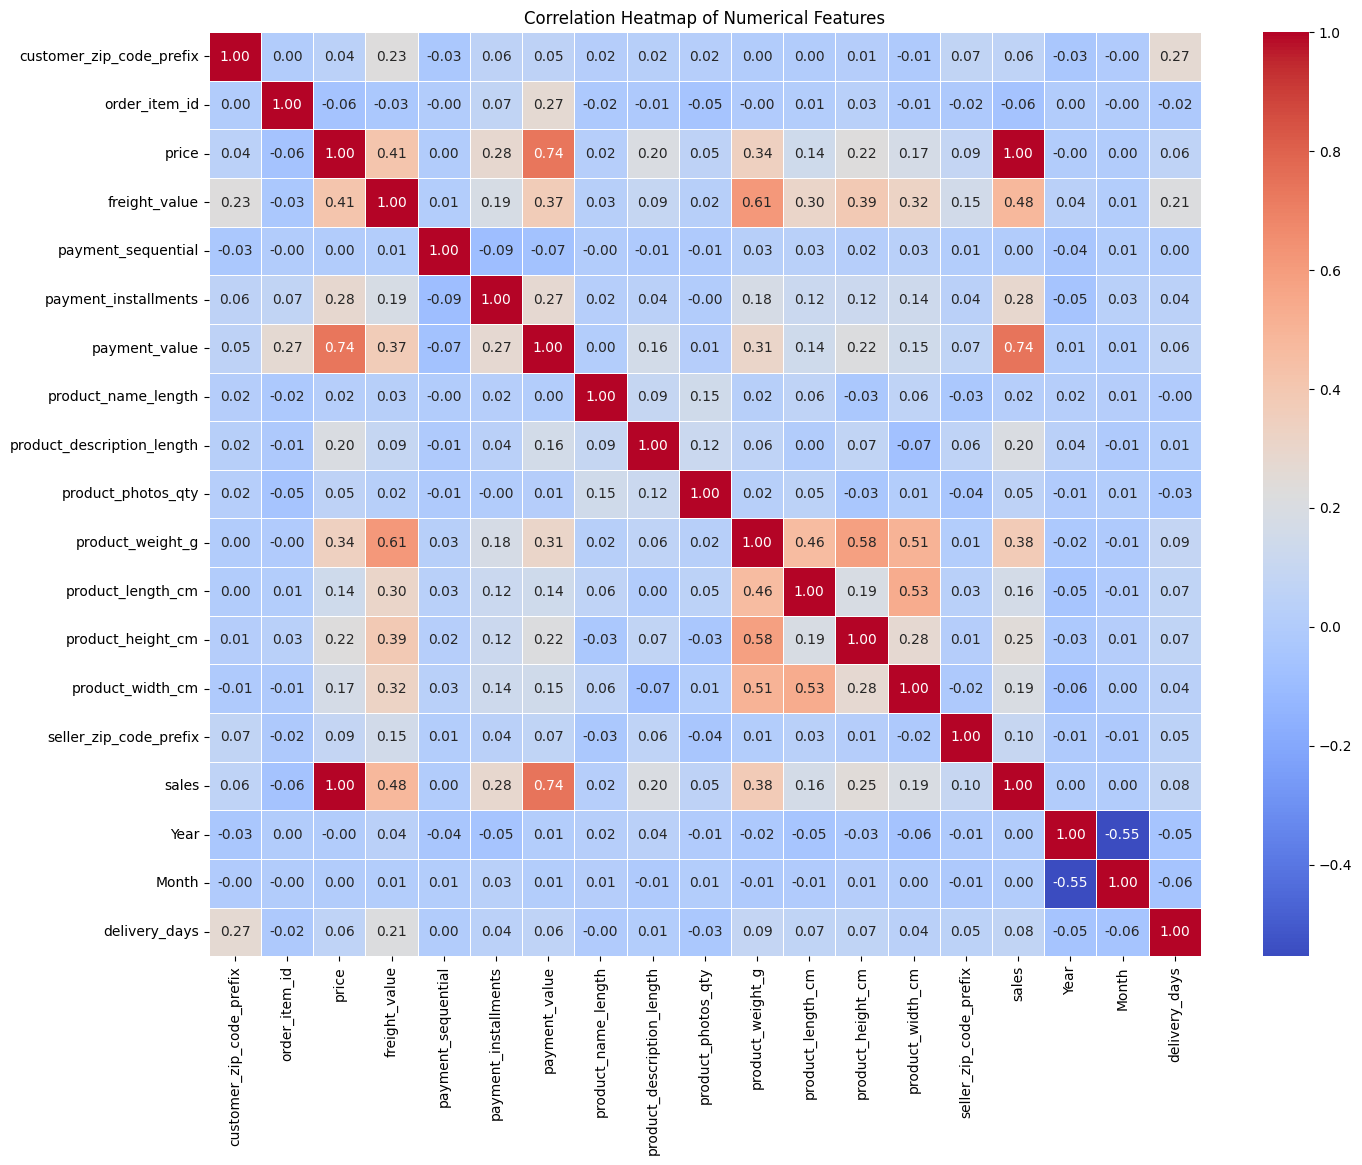

In [50]:
# select numerical columns
numerical_data = data.select_dtypes(include=[np.number])

# visualize correlation with heat map
plt.figure(figsize=(16, 12))
sns.heatmap(numerical_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# **Summary**:




This project involved a detailed exploratory data analysis of a comprehensive e-commerce dataset, encompassing customer, order, product, payment, and seller information. The primary objective was to derive actionable insights into customer behavior, sales trends, and seller performance to optimize business strategies.

**Key Findings and Insights**:

1. **Customer Demographics and Spending Patterns**:
* Geographical Concentration: São Paulo (SP) emerged as the dominant customer hub, both in terms of unique customers (Top 10 Cities and States visualizations). 'sao paulo' and 'rio de janeiro' were the leading cities by customer count, and 'SP' had the overwhelming majority of unique customers among states.
* Purchasing Behavior: The 'Items Per Order Distribution' showed that most orders consist of a single item, indicating a preference for individual product purchases rather than bulk buying. The 'Average Products Per Order by Customer City' revealed variations, with some smaller cities showing a higher average number of items per order, suggesting localized purchasing habits.
* Payment Preferences: 'Credit Card' was overwhelmingly the most used payment method, contributing the highest amount of revenue. Interestingly, 'Percentage of Orders Paid in Installments' indicated that slightly over half (51.5%) of orders utilized installment payments, highlighting the popularity and importance of flexible payment options.
2. **Key Performance Indicators (KPIs)**:
* Sales Trends: The 'Monthly Sales Trend' demonstrated an overall upward trajectory from late 2016 to mid-2018, with noticeable seasonal peaks, particularly towards the end of the year. The 'Number of Orders Per Year' further confirmed this growth, with 2018 having the highest order volume.
* Order Status: The 'Orders by Status' chart showed that the vast majority of orders were 'delivered', indicating efficient fulfillment, with a minimal number of 'canceled' orders.
* Delivery Times: The 'Delivery Time Distribution' revealed an average delivery time of approximately 12 days, with most deliveries occurring within a reasonable timeframe, though some outliers took longer.
* Order Price Distribution: Most orders fall into lower price ranges, suggesting a high volume of lower-cost goods or a customer base that is more price-sensitive.
3. **Product and Seller Performance**:
* Top Product Categories: 'HEALTH BEAUTY', 'Watches present', and 'bed table bath' consistently ranked as the top categories by both 'Total Sales' and 'Percentage of Total Revenue', clearly driving the most revenue for the platform.
* Product Price vs. Purchases: A very weak, almost negligible negative correlation (-0.03) was observed between 'Product Price and Number of Purchases'. This implies that product price alone doesn't strongly dictate purchase frequency, suggesting other factors (e.g., product utility, marketing, brand) are more influential.
* Top Sellers: Specific 'Seller IDs' were identified as leading revenue generators, indicating high-performing partners who contribute significantly to the platform's sales.
4. **Business Strategies & Recommendations**:
* Targeted Marketing: Given the high customer concentration in São Paulo and other top cities/states, focused marketing campaigns in these regions could yield higher returns. Product promotions could be tailored based on the best-performing categories like 'HEALTH BEAUTY' and 'Watches present'.
* Payment Optimization: The popularity of installment payments suggests that emphasizing and optimizing these options could further boost sales and customer satisfaction.
* Logistics & Customer Satisfaction: While average delivery times are good, investigating the causes of longer delivery outliers could enhance customer experience. Monitoring order cancellation reasons can help in improving operational processes.
* Product Portfolio: Analyzing the price distribution might suggest opportunities to either increase the volume of lower-priced items or strategically introduce higher-priced products with value-added services.
* Seller Engagement: Recognizing and supporting top-performing sellers can foster loyalty and encourage continued high sales performance. Identifying and mentoring underperforming sellers could also improve overall platform revenue.
This analysis provides a solid foundation for data-driven decision-making, enabling the e-commerce platform to understand its market, optimize operations, and enhance customer satisfaction.

#**Conclusion**:


*   **Customer Demographics and Spending Patterns**: São Paulo (SP) is the primary customer hub, leading in unique customers across cities and states. Most orders consist of a single item, with variations in average items per order across different cities. Credit Card is the most preferred payment method and generates the highest revenue, with approximately 51.5% of orders utilizing installment payments.
*   **Key Performance Indicators (KPIs)**: Monthly sales show an upward trend from late 2016 to mid-2018, with seasonal peaks. 2018 recorded the highest order volume. The vast majority of orders were successfully delivered, indicating efficient fulfillment, with a minimal number of cancellations. The average delivery time is around 12 days, and most orders fall into lower price ranges.
*   **Product and Seller Performance**: 'HEALTH BEAUTY', 'Watches present', and 'bed table bath' are consistently the top product categories by total sales and revenue percentage. There is a very weak negative correlation (-0.03) between product price and the number of purchases, suggesting price is not the sole driver of purchase frequency. Specific seller IDs were identified as high-revenue generators.



#*******************************************************************************************************************